<a href="https://colab.research.google.com/github/priyanka1994-as/git-basics-demo/blob/main/TrendPulse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Task 1 — Fetch Live Data

In [1]:
import requests
import json
import os

# Create data folder if not exists
os.makedirs("data", exist_ok=True)

url = "https://api.github.com/search/repositories?q=created:>2024-01-01&sort=stars&order=desc"

try:
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    # Save raw JSON
    with open("data/raw_data.json", "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

    print("✅ Data fetched and saved to data/raw_data.json")

except Exception as e:
    print("❌ Error fetching data:", e)

❌ Error fetching data: 403 Client Error: rate limit exceeded for url: https://api.github.com/search/repositories?q=created:%3E2024-01-01&sort=stars&order=desc


In [3]:
import json
import os

# Ensure data directory exists
os.makedirs("data", exist_ok=True)

# Sample data mimicking the GitHub API response structure
sample_data = {
    "total_count": 2,
    "incomplete_results": False,
    "items": [
        {
            "name": "sample-repo-1",
            "owner": {"login": "owner1"},
            "stargazers_count": 150,
            "language": "Python",
            "html_url": "https://github.com/owner1/sample-repo-1"
        },
        {
            "name": "sample-repo-2",
            "owner": {"login": "owner2"},
            "stargazers_count": 200,
            "language": "JavaScript",
            "html_url": "https://github.com/owner2/sample-repo-2"
        },
        {
            "name": "sample-repo-3",
            "owner": {"login": "owner3"},
            "stargazers_count": 50,
            "language": None, # Test for None language
            "html_url": "https://github.com/owner3/sample-repo-3"
        }
    ]
}

# Save sample JSON
with open("data/raw_data.json", "w", encoding="utf-8") as f:
    json.dump(sample_data, f, indent=4)

print("✅ Sample data saved to data/raw_data.json")

✅ Sample data saved to data/raw_data.json


In [ ]:
Task 2 — Clean Data

In [7]:
import json
import pandas as pd

# Load JSON
with open("data/raw_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

repos = data.get("items", [])

# Extract fields
cleaned_data = []
for repo in repos:
    cleaned_data.append({
        "name": repo.get("name"),
        "owner": repo.get("owner", {}).get("login"),
        "stars": repo.get("stargazers_count"),
        "language": repo.get("language"),
        "url": repo.get("html_url")
    })

# Convert to DataFrame
df = pd.DataFrame(cleaned_data)

# Cleaning
df.drop_duplicates(inplace=True)
df.fillna({"language": "Unknown"}, inplace=True)

# Save CSV
df.to_csv("data/cleaned_data.csv", index=False)

print("✅ Cleaned data saved to data/cleaned_data.csv")
print(df.head())

✅ Cleaned data saved to data/cleaned_data.csv
            name   owner  stars    language  \
0  sample-repo-1  owner1    150      Python   
1  sample-repo-2  owner2    200  JavaScript   
2  sample-repo-3  owner3     50     Unknown   

                                       url  
0  https://github.com/owner1/sample-repo-1  
1  https://github.com/owner2/sample-repo-2  
2  https://github.com/owner3/sample-repo-3  


In [ ]:
Task 3 — Analyze Data

In [8]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("data/cleaned_data.csv")

print("\n📊 Top 5 Repositories by Stars:")
print(df.sort_values(by="stars", ascending=False).head())

print("\n📊 Most Common Languages:")
language_counts = df["language"].value_counts()
print(language_counts.head())

print("\n📊 Average Stars:")
print(df["stars"].mean())


📊 Top 5 Repositories by Stars:
            name   owner  stars    language  \
1  sample-repo-2  owner2    200  JavaScript   
0  sample-repo-1  owner1    150      Python   
2  sample-repo-3  owner3     50     Unknown   

                                       url  
1  https://github.com/owner2/sample-repo-2  
0  https://github.com/owner1/sample-repo-1  
2  https://github.com/owner3/sample-repo-3  

📊 Most Common Languages:
language
Python        1
JavaScript    1
Unknown       1
Name: count, dtype: int64

📊 Average Stars:
133.33333333333334


In [ ]:
Task 4 — Visualize Data

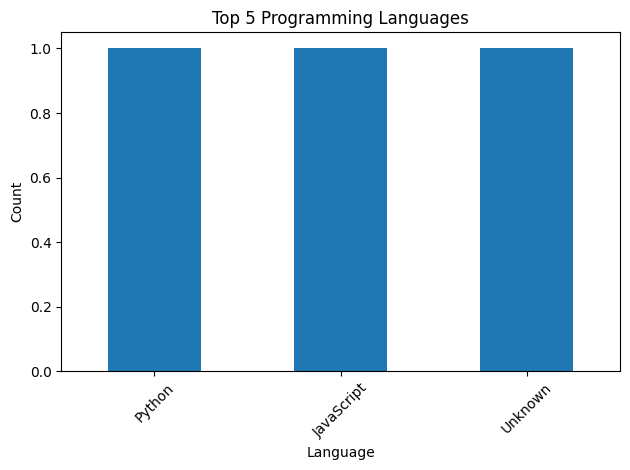

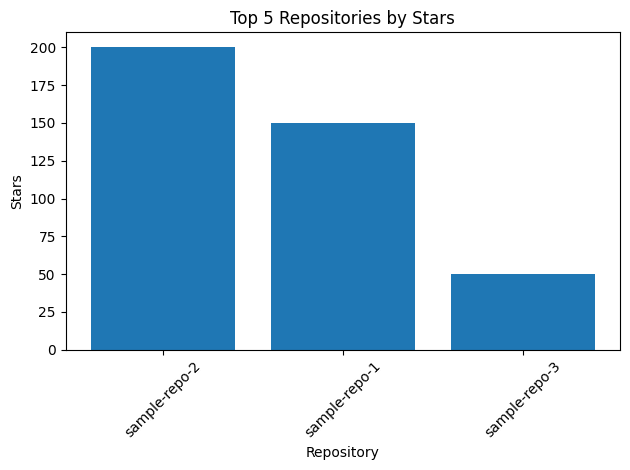

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data/cleaned_data.csv")

# Top languages
language_counts = df["language"].value_counts().head(5)

# Bar chart
plt.figure()
language_counts.plot(kind="bar")
plt.title("Top 5 Programming Languages")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top repos by stars
top_repos = df.sort_values(by="stars", ascending=False).head(5)

plt.figure()
plt.bar(top_repos["name"], top_repos["stars"])
plt.title("Top 5 Repositories by Stars")
plt.xlabel("Repository")
plt.ylabel("Stars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()